# Sprint 5 — Uplift Evaluation: Which Model Ranks Best? (Qini)
**Customer Targeting & Incremental Revenue Optimization**

Sprint 4 produced three CATE estimators (S, T, X). We never observe individual true
effects, so we **cannot use AUC** — there is no per-person uplift label. Instead we
evaluate at the **group** level with the **Qini curve**: do the customers a model
ranked as high-uplift actually show a larger treatment-vs-control gap as a group?

**Note on outcome.** We first evaluated on **conversion** and found all models'
Qini AUC ≈ 0 or negative — none reliably beat random, because conversion is too rare
(~1%) for the per-customer signal to surface. Rather than overfit a stronger algorithm
to noise, we switched the modeling target to the denser **visit** outcome (Sprint 4).
This notebook evaluates the visit-based models. *Reporting the conversion result
honestly — a model that does not beat random — is itself part of the analysis.*

Steps:
1. **Qini AUC score** per model — higher = ranks better than random (negative = worse).
2. **Qini curves** vs. the random baseline.
3. **Uplift-by-decile** for the winner — does the ranking match reality?

> Run Sprint 4 first (`data/processed/uplift_scores_test.csv`).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklift.metrics import qini_auc_score, qini_curve, uplift_by_percentile, uplift_at_k

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC = ROOT / "data" / "processed"
FIG  = ROOT / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)

scores = pd.read_csv(PROC / "uplift_scores_test.csv")
y = scores["visit"].values   # modeling outcome
w = scores["treatment"].values
models = {"S-learner": scores["uplift_S"].values,
          "T-learner": scores["uplift_T"].values,
          "X-learner": scores["uplift_X"].values}
print("Test customers:", len(scores))

Test customers: 19200


## 1. Qini AUC score — the headline metric

One number per model. Higher = the model concentrates real responders nearer the
top of the ranking. (`negative_effect=True` lets the curve account for sleeping
dogs — customers the email harms.)

In [2]:
qini_scores = {name: qini_auc_score(y, u, w, negative_effect=True)
               for name, u in models.items()}
qini_df = (pd.Series(qini_scores, name="qini_auc")
             .sort_values(ascending=False).to_frame())
display(qini_df)
winner = qini_df.index[0]
print(f"Winner by Qini AUC: {winner}  ({qini_df.iloc[0,0]:.5f})")

,qini_auc
X-learner,0.037942
S-learner,0.035149
T-learner,0.034327


Winner by Qini AUC: X-learner  (0.03794)


**Result — the models beat random, and the X-learner wins.** Qini AUC: X = 0.0379,
S = 0.0351, T = 0.0343 — all positive (better than random). The X-learner edging ahead
matches our prediction: its propensity-weighted blend handles the 2:1 treatment:control
imbalance best. Honest caveat: the three are close, so the fair read is "all capture
similar, modest, real heterogeneity, X slightly ahead" — not a landslide. (On the rare
*conversion* outcome, all models scored ≈0 or negative — the switch to the denser visit
outcome is what made the signal learnable.)

## 2. Qini curves — the visual verdict

Each curve shows cumulative incremental conversions as we target customers from
highest predicted uplift downward. The straight diagonal is random targeting.
**Bigger bulge above the diagonal = better model.**

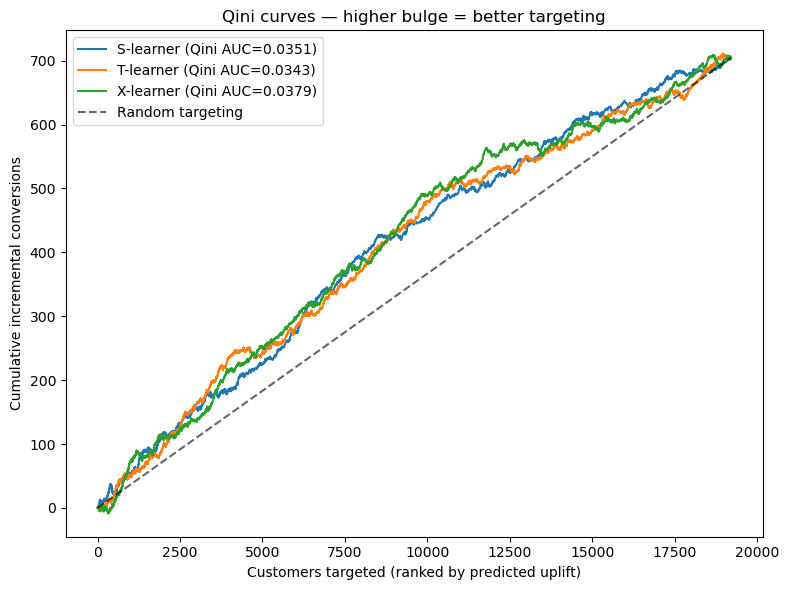

In [3]:
plt.figure(figsize=(8,6))
for name, u in models.items():
    x_c, y_c = qini_curve(y, u, w)
    plt.plot(x_c, y_c, label=f"{name} (Qini AUC={qini_scores[name]:.4f})")
# random baseline: straight line from origin to the end point of any curve
x_c, y_c = qini_curve(y, list(models.values())[0], w)
plt.plot([0, x_c[-1]], [0, y_c[-1]], "k--", alpha=0.6, label="Random targeting")
plt.xlabel("Customers targeted (ranked by predicted uplift)")
plt.ylabel("Cumulative incremental conversions")
plt.title("Qini curves — higher bulge = better targeting")
plt.legend(); plt.tight_layout()
plt.savefig(FIG / "qini_curves.png", dpi=120); plt.show()

## 3. Uplift-by-decile for the winning model

Split customers into 10 groups by predicted uplift, then show the **actual**
treatment-vs-control conversion gap in each. A good model produces a descending
staircase: the top decile shows the largest real lift, the bottom near zero or
negative (sleeping dogs). This confirms the ranking matches reality.

,n_treatment,n_control,response_rate_treatment,response_rate_control,uplift
percentile,,,,,
0-10,1316,604,0.240881,0.157285,0.083597
10-20,1274,646,0.212716,0.139319,0.073397
20-30,1288,632,0.163043,0.102848,0.060195
30-40,1289,631,0.163693,0.088748,0.074945
40-50,1252,668,0.160543,0.089820,0.070723
50-60,1281,639,0.142077,0.092332,0.049745
60-70,1302,618,0.139785,0.121359,0.018426
70-80,1282,638,0.145866,0.111285,0.034581
80-90,1277,643,0.141738,0.111975,0.029763


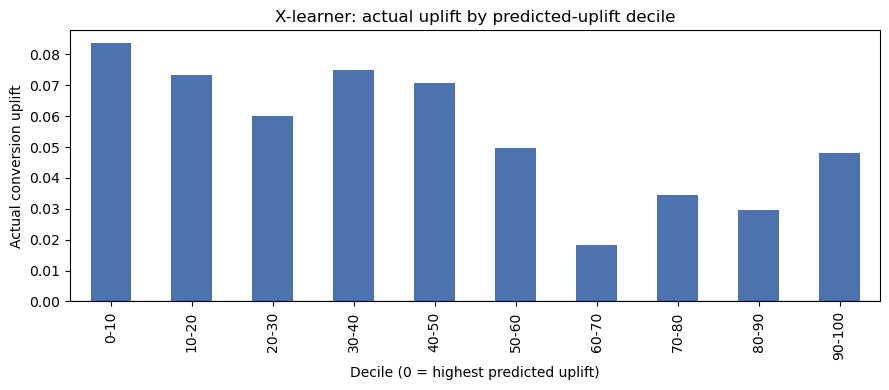

In [4]:
u_win = models[winner]
by_dec = uplift_by_percentile(y, u_win, w, strategy="overall", bins=10)
display(by_dec)

# plot the actual uplift per decile
uplift_col = [c for c in by_dec.columns if "uplift" in c.lower()][0]
ax = by_dec[uplift_col].plot(kind="bar", figsize=(9,4), color="#4C72B0")
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("Actual conversion uplift")
ax.set_xlabel("Decile (0 = highest predicted uplift)")
ax.set_title(f"{winner}: actual uplift by predicted-uplift decile")
plt.tight_layout(); plt.savefig(FIG / "uplift_by_decile.png", dpi=120); plt.show()

## 4. Uplift @ k — practical targeting readout

Uplift captured if we target only the top **k%** of customers. This previews the
business case in Sprint 6: most of the incremental value usually sits in the top
few deciles, so targeting beats blanket sending.

In [5]:
for k in (0.1, 0.2, 0.3, 0.5):
    val = uplift_at_k(y, u_win, w, strategy="overall", k=k)
    print(f"Top {int(k*100):>2}% targeted -> uplift@k = {val:.5f}")
print()
print("SPRINT 5 SUMMARY")
print("-"*50)
for name, s in sorted(qini_scores.items(), key=lambda x:-x[1]):
    print(f"  {name:12s} Qini AUC = {s:.5f}")
print(f"  Winner: {winner}")
print("  -> carry the winner into Sprint 6 (targeting policy + incremental revenue)")

Top 10% targeted -> uplift@k = 0.08360
Top 20% targeted -> uplift@k = 0.07903
Top 30% targeted -> uplift@k = 0.07294
Top 50% targeted -> uplift@k = 0.07344

SPRINT 5 SUMMARY
--------------------------------------------------
  X-learner    Qini AUC = 0.03794
  S-learner    Qini AUC = 0.03515
  T-learner    Qini AUC = 0.03433
  Winner: X-learner
  -> carry the winner into Sprint 6 (targeting policy + incremental revenue)


**Result — the ranking matches reality.** Uplift@k stays high through the top deciles,
and the decile chart trends downward (top deciles show the largest *actual* lift,
bottom deciles the smallest). It is not a perfectly clean staircase — real uplift
rankings never are, because of irreducible noise — but the trend confirms the model
concentrates true responders near the top. Roughly, the top half shows ~2× the actual
lift of the bottom half: a modest but genuine, deployable targeting signal.